# LDA and NN+LDA with PyTorch SGD (Fixed Variance)

This notebook:
- generates two 1D Gaussian classes,
- trains a regular LDA model using `LDAHead` from `lda_head.py`,
- trains a one-hidden-layer NN + LDA head,
- uses PyTorch `torch.optim.Adam` for optimization,
- keeps shared variance fixed at `1.0` in both models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from lda_head import LDAHead

torch.manual_seed(7)
rng = np.random.default_rng(7)
device = torch.device('cpu')
sigma2_fixed = 1.0

def normal_pdf(x, mu, sigma2):
    return (1.0 / np.sqrt(2.0 * np.pi * sigma2)) * np.exp(-0.5 * (x - mu) ** 2 / sigma2)

In [2]:
# Generate synthetic data
n0, n1 = 250, 250
mu0_true, mu1_true = -2.0, 2.0
sigma_true = 1.0

x0 = rng.normal(mu0_true, sigma_true, n0)
x1 = rng.normal(mu1_true, sigma_true, n1)
X = np.concatenate([x0, x1])
y = np.concatenate([np.zeros(n0, dtype=np.int64), np.ones(n1, dtype=np.int64)])

x_t = torch.tensor(X[:, None], dtype=torch.float32, device=device)
y_t = torch.tensor(y, dtype=torch.long, device=device)

print(f'n={len(X)}, true means=({mu0_true}, {mu1_true}), fixed sigma^2={sigma2_fixed}')

n=500, true means=(-2.0, 2.0), fixed sigma^2=1.0


In [3]:
# Regular LDA trained with torch.optim.Adam + torch.nn.NLLLoss
lda_head = LDAHead(C=2, D=1, fixed_variance=sigma2_fixed, train_priors=False).to(device)
opt_lda = torch.optim.SGD(lda_head.parameters(), lr=.01)
criterion = nn.NLLLoss()

loss_lda_hist = []
steps_lda = 3000
for _ in range(steps_lda):
    opt_lda.zero_grad(set_to_none=True)
    log_joint = lda_head(x_t)
    log_probs = torch.log_softmax(log_joint, dim=1)
    loss = criterion(log_probs, y_t)
    loss.backward()
    opt_lda.step()
    loss_lda_hist.append(float(loss.detach().cpu()))

with torch.no_grad():
    mu_lda = lda_head.mu.detach().cpu().numpy().squeeze(-1)
    pi_lda = lda_head.priors().detach().cpu().numpy()

mu0_hat, mu1_hat = float(mu_lda[0]), float(mu_lda[1])
pi0_hat, pi1_hat = float(pi_lda[0]), float(pi_lda[1])

print(f'Regular LDA final loss: {loss_lda_hist[-1]:.4f}')
print(f'Learned means: mu0={mu0_hat:.4f}, mu1={mu1_hat:.4f}')
print(f'Learned priors: pi0={pi0_hat:.4f}, pi1={pi1_hat:.4f}')

Regular LDA final loss: 0.0470
Learned means: mu0=-1.6125, mu1=1.3564
Learned priors: pi0=0.5000, pi1=0.5000


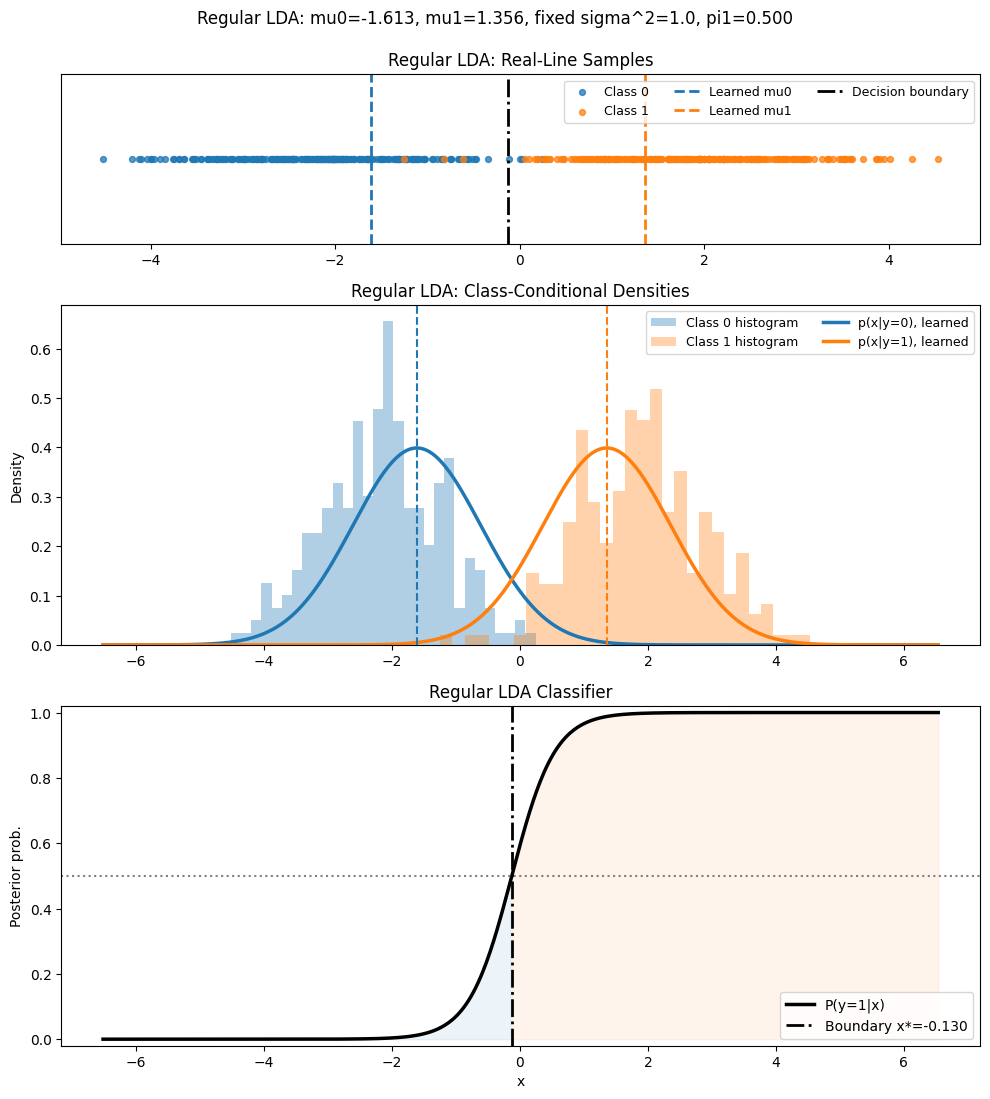

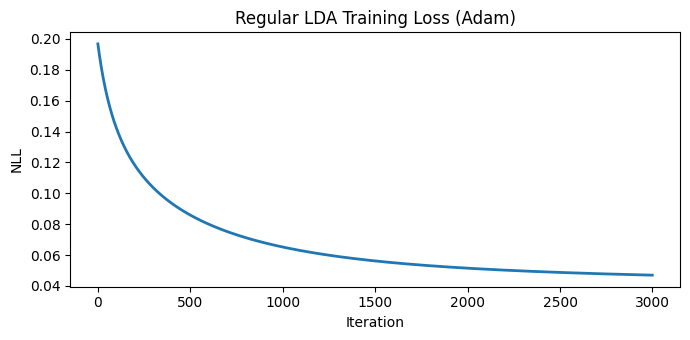

In [4]:
# Regular LDA visualizations
xx = np.linspace(X.min() - 2.0, X.max() + 2.0, 700)
p_x_y0 = normal_pdf(xx, mu0_hat, sigma2_fixed)
p_x_y1 = normal_pdf(xx, mu1_hat, sigma2_fixed)
p_y1_x = (pi1_hat * p_x_y1) / (pi0_hat * p_x_y0 + pi1_hat * p_x_y1 + 1e-12)
x_star = float(xx[np.argmin(np.abs(p_y1_x - 0.5))])

fig, axes = plt.subplots(3, 1, figsize=(10, 11), gridspec_kw={'height_ratios': [1, 2, 2]})

axes[0].scatter(X[y == 0], np.zeros((y == 0).sum()), s=18, alpha=0.75, color='#1f77b4', label='Class 0')
axes[0].scatter(X[y == 1], np.zeros((y == 1).sum()), s=18, alpha=0.75, color='#ff7f0e', label='Class 1')
axes[0].axvline(mu0_hat, color='#1f77b4', linestyle='--', linewidth=2, label='Learned mu0')
axes[0].axvline(mu1_hat, color='#ff7f0e', linestyle='--', linewidth=2, label='Learned mu1')
axes[0].axvline(x_star, color='black', linestyle='-.', linewidth=2, label='Decision boundary')
axes[0].set_yticks([])
axes[0].set_title('Regular LDA: Real-Line Samples')
axes[0].legend(ncol=3, fontsize=9, loc='upper right')

axes[1].hist(X[y == 0], bins=30, density=True, alpha=0.35, color='#1f77b4', label='Class 0 histogram')
axes[1].hist(X[y == 1], bins=30, density=True, alpha=0.35, color='#ff7f0e', label='Class 1 histogram')
axes[1].plot(xx, p_x_y0, color='#1f77b4', linewidth=2.5, label='p(x|y=0), learned')
axes[1].plot(xx, p_x_y1, color='#ff7f0e', linewidth=2.5, label='p(x|y=1), learned')
axes[1].axvline(mu0_hat, color='#1f77b4', linestyle='--', linewidth=1.5)
axes[1].axvline(mu1_hat, color='#ff7f0e', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('Density')
axes[1].set_title('Regular LDA: Class-Conditional Densities')
axes[1].legend(fontsize=9, ncol=2)

axes[2].plot(xx, p_y1_x, color='black', linewidth=2.5, label='P(y=1|x)')
axes[2].axhline(0.5, color='gray', linestyle=':', linewidth=1.5)
axes[2].axvline(x_star, color='black', linestyle='-.', linewidth=2, label=f'Boundary x*={x_star:.3f}')
axes[2].fill_between(xx, 0, p_y1_x, where=(xx < x_star), color='#1f77b4', alpha=0.08)
axes[2].fill_between(xx, 0, p_y1_x, where=(xx >= x_star), color='#ff7f0e', alpha=0.08)
axes[2].set_ylim(-0.02, 1.02)
axes[2].set_xlabel('x')
axes[2].set_ylabel('Posterior prob.')
axes[2].set_title('Regular LDA Classifier')
axes[2].legend(loc='lower right')

fig.suptitle(f'Regular LDA: mu0={mu0_hat:.3f}, mu1={mu1_hat:.3f}, fixed sigma^2={sigma2_fixed:.1f}, pi1={pi1_hat:.3f}', y=0.995)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(loss_lda_hist, linewidth=2)
plt.title('Regular LDA Training Loss (Adam)')
plt.xlabel('Iteration')
plt.ylabel('NLL')
plt.tight_layout()
plt.show()

In [5]:
# One-hidden-layer NN feature map + LDAHead
class OneHiddenNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        return self.fc2(h)

class NNWithLDA(nn.Module):
    def __init__(self, hidden_dim=256, sigma2=1.0):
        super().__init__()
        self.feature = OneHiddenNet(hidden_dim=hidden_dim)
        self.head = LDAHead(C=2, D=1, fixed_variance=sigma2, train_priors=False)

    def forward(self, x):
        z = self.feature(x)
        return self.head(z), z

nn_lda = NNWithLDA(hidden_dim=8, sigma2=sigma2_fixed).to(device)
opt_nn_lda = torch.optim.SGD(nn_lda.parameters(), lr=.01)
criterion_nn = nn.NLLLoss()

loss_nn_hist = []
steps_nn = 4000
for _ in range(steps_nn):
    opt_nn_lda.zero_grad(set_to_none=True)
    log_joint, z_batch = nn_lda(x_t)
    log_probs = torch.log_softmax(log_joint, dim=1)
    loss = criterion_nn(log_probs, y_t)
    loss.backward()
    opt_nn_lda.step()
    loss_nn_hist.append(float(loss.detach().cpu()))

with torch.no_grad():
    z_hat = nn_lda.feature(x_t).detach().cpu().numpy().squeeze(-1)
    mu_z = nn_lda.head.mu.detach().cpu().numpy().squeeze(-1)
    pi_z = nn_lda.head.priors().detach().cpu().numpy()

mu0_z, mu1_z = float(mu_z[0]), float(mu_z[1])
pi0_z, pi1_z = float(pi_z[0]), float(pi_z[1])

print(f'NN+LDA final loss: {loss_nn_hist[-1]:.4f}')
print(f'Learned latent means: mu0={mu0_z:.4f}, mu1={mu1_z:.4f}')
print(f'Learned priors: pi0={pi0_z:.4f}, pi1={pi1_z:.4f}')

NN+LDA final loss: 0.0408
Learned latent means: mu0=1.4051, mu1=-1.0457
Learned priors: pi0=0.5000, pi1=0.5000


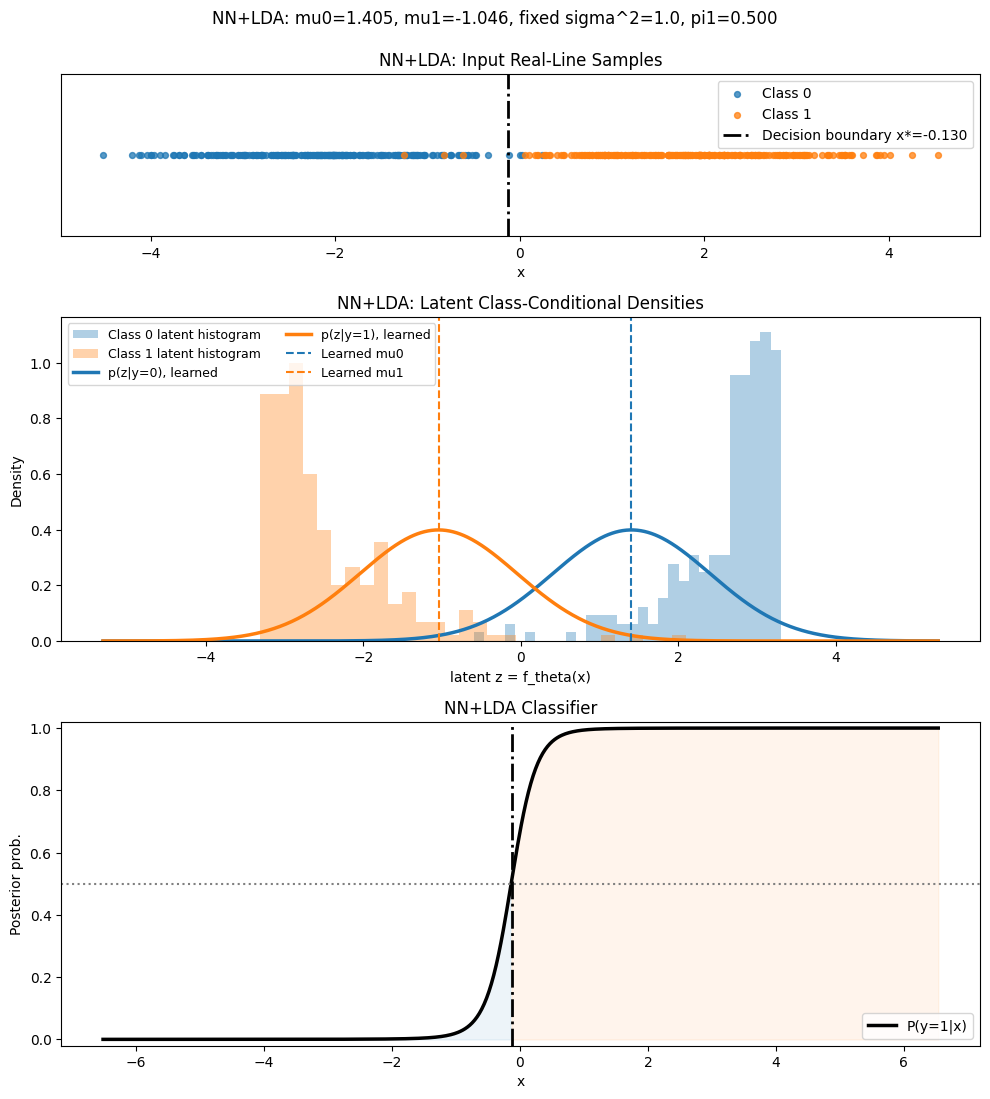

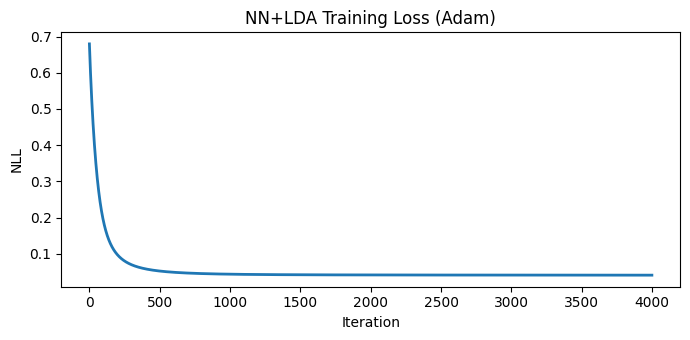

In [6]:
# NN+LDA visualizations
xx_nn = np.linspace(X.min() - 2.0, X.max() + 2.0, 700)
with torch.no_grad():
    z_grid = nn_lda.feature(torch.tensor(xx_nn[:, None], dtype=torch.float32, device=device)).cpu().numpy().squeeze(-1)

p_z_y0_grid = normal_pdf(z_grid, mu0_z, sigma2_fixed)
p_z_y1_grid = normal_pdf(z_grid, mu1_z, sigma2_fixed)
p_y1_x_nn = (pi1_z * p_z_y1_grid) / (pi0_z * p_z_y0_grid + pi1_z * p_z_y1_grid + 1e-12)
x_star_nn = float(xx_nn[np.argmin(np.abs(p_y1_x_nn - 0.5))])

z_line = np.linspace(z_hat.min() - 2.0, z_hat.max() + 2.0, 700)
p0_line = normal_pdf(z_line, mu0_z, sigma2_fixed)
p1_line = normal_pdf(z_line, mu1_z, sigma2_fixed)

fig, axes = plt.subplots(3, 1, figsize=(10, 11), gridspec_kw={'height_ratios': [1, 2, 2]})

axes[0].scatter(X[y == 0], np.zeros((y == 0).sum()), s=18, alpha=0.75, color='#1f77b4', label='Class 0')
axes[0].scatter(X[y == 1], np.zeros((y == 1).sum()), s=18, alpha=0.75, color='#ff7f0e', label='Class 1')
axes[0].axvline(x_star_nn, color='black', linestyle='-.', linewidth=2, label=f'Decision boundary x*={x_star_nn:.3f}')
axes[0].set_yticks([])
axes[0].set_xlabel('x')
axes[0].set_title('NN+LDA: Input Real-Line Samples')
axes[0].legend(loc='upper right')

axes[1].hist(z_hat[y == 0], bins=30, density=True, alpha=0.35, color='#1f77b4', label='Class 0 latent histogram')
axes[1].hist(z_hat[y == 1], bins=30, density=True, alpha=0.35, color='#ff7f0e', label='Class 1 latent histogram')
axes[1].plot(z_line, p0_line, color='#1f77b4', linewidth=2.5, label='p(z|y=0), learned')
axes[1].plot(z_line, p1_line, color='#ff7f0e', linewidth=2.5, label='p(z|y=1), learned')
axes[1].axvline(mu0_z, color='#1f77b4', linestyle='--', linewidth=1.5, label='Learned mu0')
axes[1].axvline(mu1_z, color='#ff7f0e', linestyle='--', linewidth=1.5, label='Learned mu1')
axes[1].set_xlabel('latent z = f_theta(x)')
axes[1].set_ylabel('Density')
axes[1].set_title('NN+LDA: Latent Class-Conditional Densities')
axes[1].legend(fontsize=9, ncol=2)

axes[2].plot(xx_nn, p_y1_x_nn, color='black', linewidth=2.5, label='P(y=1|x)')
axes[2].axhline(0.5, color='gray', linestyle=':', linewidth=1.5)
axes[2].axvline(x_star_nn, color='black', linestyle='-.', linewidth=2)
axes[2].fill_between(xx_nn, 0, p_y1_x_nn, where=(xx_nn < x_star_nn), color='#1f77b4', alpha=0.08)
axes[2].fill_between(xx_nn, 0, p_y1_x_nn, where=(xx_nn >= x_star_nn), color='#ff7f0e', alpha=0.08)
axes[2].set_ylim(-0.02, 1.02)
axes[2].set_xlabel('x')
axes[2].set_ylabel('Posterior prob.')
axes[2].set_title('NN+LDA Classifier')
axes[2].legend(loc='lower right')

fig.suptitle(f'NN+LDA: mu0={mu0_z:.3f}, mu1={mu1_z:.3f}, fixed sigma^2={sigma2_fixed:.1f}, pi1={pi1_z:.3f}', y=0.995)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(loss_nn_hist, linewidth=2)
plt.title('NN+LDA Training Loss (Adam)')
plt.xlabel('Iteration')
plt.ylabel('NLL')
plt.tight_layout()
plt.show()